# 06a - Tipologias agroclimaticas del territorio (Opcion A)

**Objetivo:** agrupar las **zonas climaticas** (distrito proxy NASA) del dataset segun su
clima 2020-2025. La produccion **no** entra al clustering: es una variable **descriptiva**
que caracteriza cada zona *a posteriori*.

| Campo | Valor |
|-------|-------|
| Unidad de analisis | 1 fila por **distrito / zona climatica** (~12 zonas) |
| Input clustering | medias y desv. estandar climaticas (CLIMA_CORE) |
| Produccion | descriptiva (boxplots por cluster), no input |

**Por que esta version:** en `dataset_integrado` el clima es constante por (region, piso),
de modo que las 33 filas `(region, cultivo)` solo replican ~12 vectores climaticos distintos.
Clusterizar perfiles `(region, cultivo)` con features climaticas equivale a clusterizar
distritos con cada uno repetido N veces. Aqui se clusteriza directamente la unidad real:
**la zona climatica**. La interpretacion es limpia: *tipologias agroclimaticas del territorio*.


## 1. Importaciones

In [1]:
# ====================================================================
# Importaciones
# ====================================================================
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
sns.set_style("whitegrid")
PALETTE = sns.color_palette("tab10")
print("Librerias cargadas")



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\USER\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\USER\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\USER\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\USER\anaconda3\Lib\site-packages

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\USER\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\USER\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\USER\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\USER\anaconda3\Lib\site-packages

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



Librerias cargadas


## 2. Carga de datos

In [2]:
# ====================================================================
# Carga de dataset_integrado.csv y rutas de salida
# ====================================================================
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent.parent
elif ROOT.name == "Clustering":
    ROOT = ROOT.parent

RUTA_DATA = ROOT / "OUTPUTS" / "dataset_integrado.csv"
RUTA_OUT = ROOT / "OUTPUTS"
RUTA_FIG = RUTA_OUT / "figures"
RUTA_FIG.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RUTA_DATA)

CLIMA_VARS = [
    "temp_promedio", "temp_maxima", "temp_minima", "precipitacion",
    "humedad_relativa", "radiacion_solar", "velocidad_viento",
    "presion_atmosferica", "humedad_suelo", "temp_superficie",
    "punto_rocio", "humedad_especifica",
]
CLIMA_CORE = [
    "temp_promedio", "precipitacion", "humedad_relativa",
    "radiacion_solar", "humedad_suelo",
]

print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print("Regiones :", sorted(df["region"].unique()))
print("Distritos:", df["distrito"].nunique(), "| Pisos:", sorted(df["piso_ecologico"].unique()))
print("Cultivos :", df["cultivo"].nunique())


Dimensiones: 2,376 filas x 20 columnas
Regiones : ['Ica', 'Junin', 'La Libertad', 'Piura', 'Puno', 'San Martin']
Distritos: 12 | Pisos: ['altiplano_lacustre', 'bosque_seco', 'costa', 'puna_alta', 'selva_alta', 'selva_alto_mayo', 'selva_baja', 'selva_huallaga', 'sierra', 'valle_chira']
Cultivos : 19


In [3]:
# ====================================================================
# Funciones auxiliares de seleccion de K (reutilizables)
# ====================================================================
def eval_kmeans_range(X, k_range, random_state=42):
    """Barrido de K: inercia, Silhouette, Calinski-Harabasz, Davies-Bouldin."""
    rows = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        lbl = km.fit_predict(X)
        rows.append({
            "k": k, "inertia": km.inertia_,
            "silhouette": silhouette_score(X, lbl),
            "calinski": calinski_harabasz_score(X, lbl),
            "davies_bouldin": davies_bouldin_score(X, lbl),
        })
    return pd.DataFrame(rows)


def elegir_k(df_km):
    """K optimo: coincidencia Silhouette/Davies-Bouldin, o ranking promedio."""
    best_sil = int(df_km.loc[df_km["silhouette"].idxmax(), "k"])
    best_db = int(df_km.loc[df_km["davies_bouldin"].idxmin(), "k"])
    if best_sil == best_db:
        return best_sil, "coincidencia Silhouette y Davies-Bouldin"
    rank_sil = df_km.set_index("k")["silhouette"].rank(ascending=False)
    rank_db = df_km.set_index("k")["davies_bouldin"].rank(ascending=True)
    k_opt = int((rank_sil + rank_db).idxmin())
    return k_opt, f"ranking promedio (Sil={best_sil}, DB={best_db})"


def plot_k_selection(df_km, titulo):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(df_km["k"], df_km["inertia"], "o-"); axes[0].set_title("Inercia (codo)")
    axes[1].plot(df_km["k"], df_km["silhouette"], "o-", color="green"); axes[1].set_title("Silhouette (mayor=mejor)")
    axes[2].plot(df_km["k"], df_km["davies_bouldin"], "o-", color="red"); axes[2].set_title("Davies-Bouldin (menor=mejor)")
    for ax in axes:
        ax.set_xlabel("K")
    plt.suptitle(titulo, fontweight="bold"); plt.tight_layout(); plt.show()


## 3. Construccion de la tabla de zonas (unidad real)

Una fila por distrito. Cada distrito pertenece a una sola region y un solo piso ecologico,
y tiene un unico vector climatico (constante en el dataset). Se resume con la media y la
desviacion estandar temporal de cada variable CLIMA_CORE.


In [4]:
# ====================================================================
# Tabla de zonas climaticas: 1 fila por distrito
# ====================================================================
# Cada distrito = 1 zona climatica unica. Agregamos clima (media y std temporal).
# La produccion se agrega aparte como variable DESCRIPTIVA (no entra al clustering).
agg_clima = {}
for v in CLIMA_CORE:
    agg_clima[f"{v}_mean"] = (v, "mean")
    agg_clima[f"{v}_std"] = (v, "std")

zonas = df.groupby(["distrito", "region", "piso_ecologico"], as_index=False).agg(**agg_clima)
zonas["etiqueta"] = zonas["region"] + " | " + zonas["distrito"]

FEATURES_ZONA = [c for c in zonas.columns if c.endswith("_mean") or c.endswith("_std")]
scaler = StandardScaler()
X_zona = scaler.fit_transform(zonas[FEATURES_ZONA])

print(f"Zonas climaticas: {len(zonas)} | features: {len(FEATURES_ZONA)}")
print(zonas[["distrito", "region", "piso_ecologico"]].to_string(index=False))


Zonas climaticas: 12 | features: 10
    distrito      region     piso_ecologico
     Ayaviri        Puno          puna_alta
Chincha Alta         Ica              costa
    El Tambo       Junin             sierra
  Huamachuco La Libertad             sierra
       Ilave        Puno altiplano_lacustre
   Moyobamba  San Martin    selva_alto_mayo
      Perene       Junin         selva_alta
   Rio Tambo       Junin         selva_baja
     Sullana       Piura        valle_chira
 Tambogrande       Piura        bosque_seco
     Tocache  San Martin     selva_huallaga
        Viru La Libertad              costa


## 4. Seleccion de K y clustering

Barrido K=2..6 (pocas unidades: ~12 zonas). KMeans como metodo principal y jerarquico Ward
como validacion de la estructura.


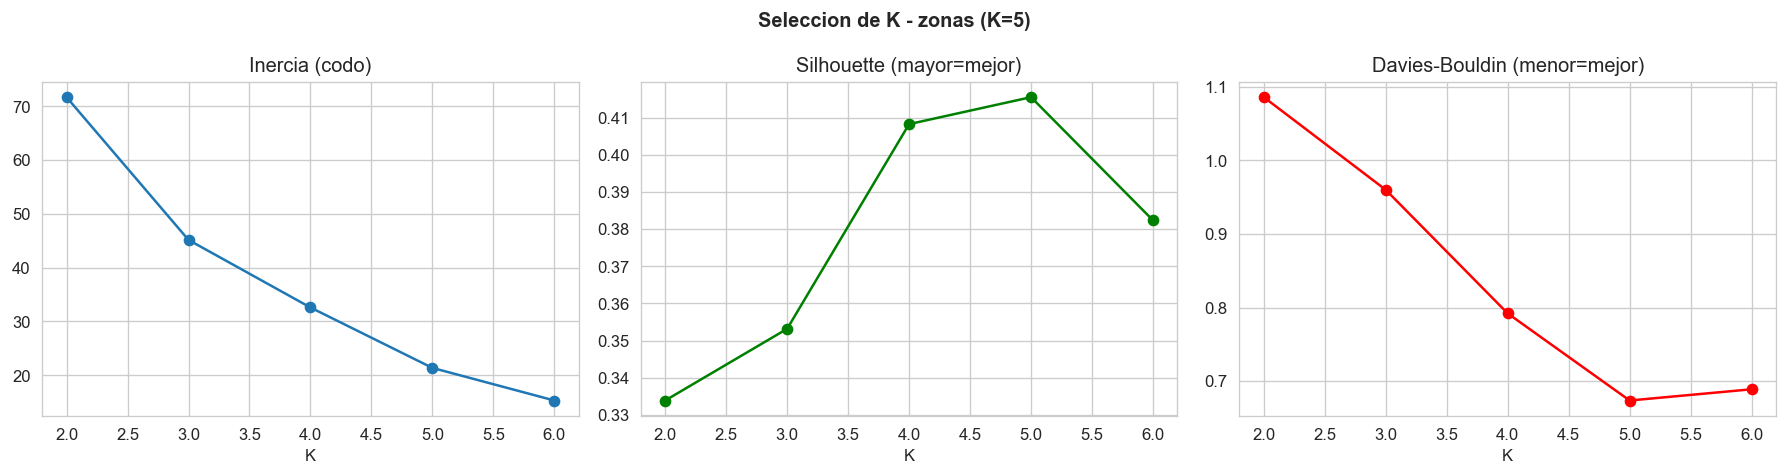

K optimo: 5 (coincidencia Silhouette y Davies-Bouldin)
KMeans K=5 | Silhouette=0.415 | Davies-Bouldin=0.674


In [5]:
# ====================================================================
# KMeans sobre zonas climaticas + seleccion de K
# ====================================================================
km_df = eval_kmeans_range(X_zona, k_range=range(2, 7))
K_ZONA, motivo = elegir_k(km_df)
plot_k_selection(km_df, f"Seleccion de K - zonas (K={K_ZONA})")
print(f"K optimo: {K_ZONA} ({motivo})")

km = KMeans(n_clusters=K_ZONA, random_state=42, n_init=10)
zonas["cluster"] = km.fit_predict(X_zona)
sil = silhouette_score(X_zona, zonas["cluster"])
db = davies_bouldin_score(X_zona, zonas["cluster"])
print(f"KMeans K={K_ZONA} | Silhouette={sil:.3f} | Davies-Bouldin={db:.3f}")


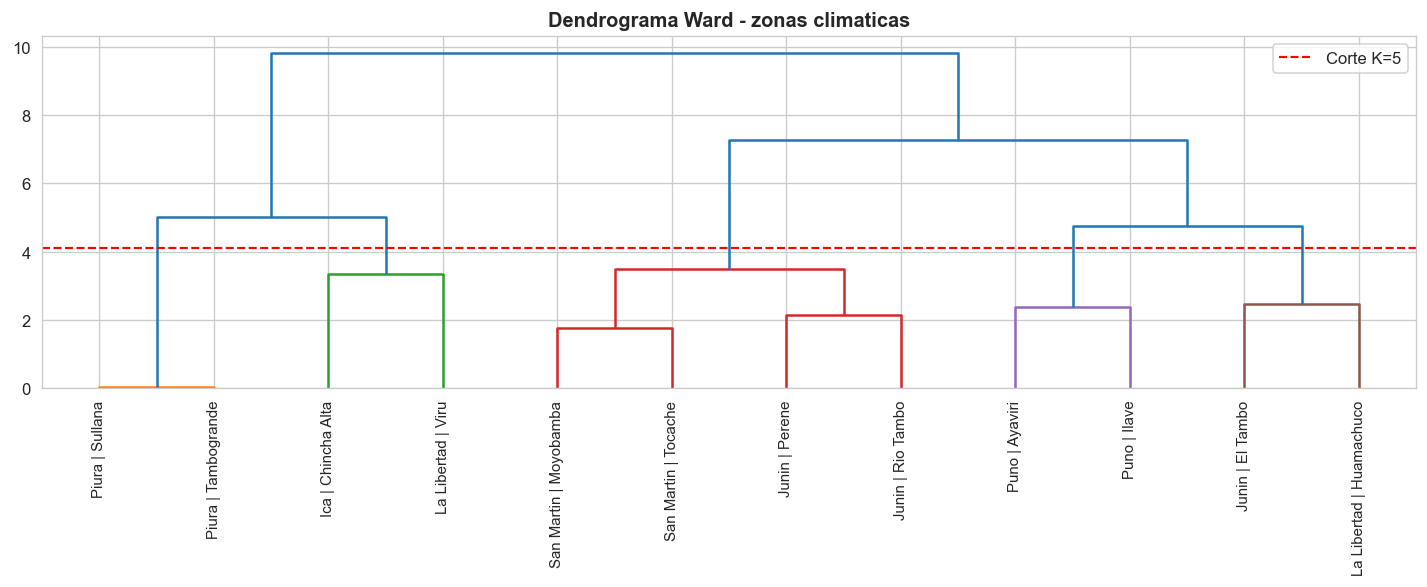

Concordancia KMeans vs jerarquico:
cluster_jerarquico  0  1  2  3  4
cluster                          
0                   0  0  2  0  0
1                   4  0  0  0  0
2                   0  2  0  0  0
3                   0  0  0  2  0
4                   0  0  0  0  2


In [6]:
# ====================================================================
# Dendrograma Ward (validacion de la estructura jerarquica)
# ====================================================================
Z = linkage(X_zona, method="ward")
# Altura de corte que produce K_ZONA clusters (linea roja discontinua).
thr = (Z[-K_ZONA, 2] + Z[-(K_ZONA - 1), 2]) / 2
fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(Z, labels=zonas["etiqueta"].tolist(), leaf_rotation=90, leaf_font_size=9,
           color_threshold=thr, ax=ax)
ax.axhline(thr, color="red", ls="--", lw=1.3, label=f"Corte K={K_ZONA}")
ax.legend(loc="upper right")
ax.set_title("Dendrograma Ward - zonas climaticas", fontweight="bold")
plt.tight_layout()
plt.savefig(RUTA_FIG / "06a_dendrograma_zonas.png", dpi=150, bbox_inches="tight")
plt.show()

hc = AgglomerativeClustering(n_clusters=K_ZONA, linkage="ward")
zonas["cluster_jerarquico"] = hc.fit_predict(X_zona)
print("Concordancia KMeans vs jerarquico:")
print(pd.crosstab(zonas["cluster"], zonas["cluster_jerarquico"]))


## 5. Interpretacion climatica de los clusters

Heatmap de centroides (clima normalizado por variable) para nombrar cada tipologia
agroclimatica: costa arida, costa norte calida, sierra templada, altiplano frio, selva humeda.


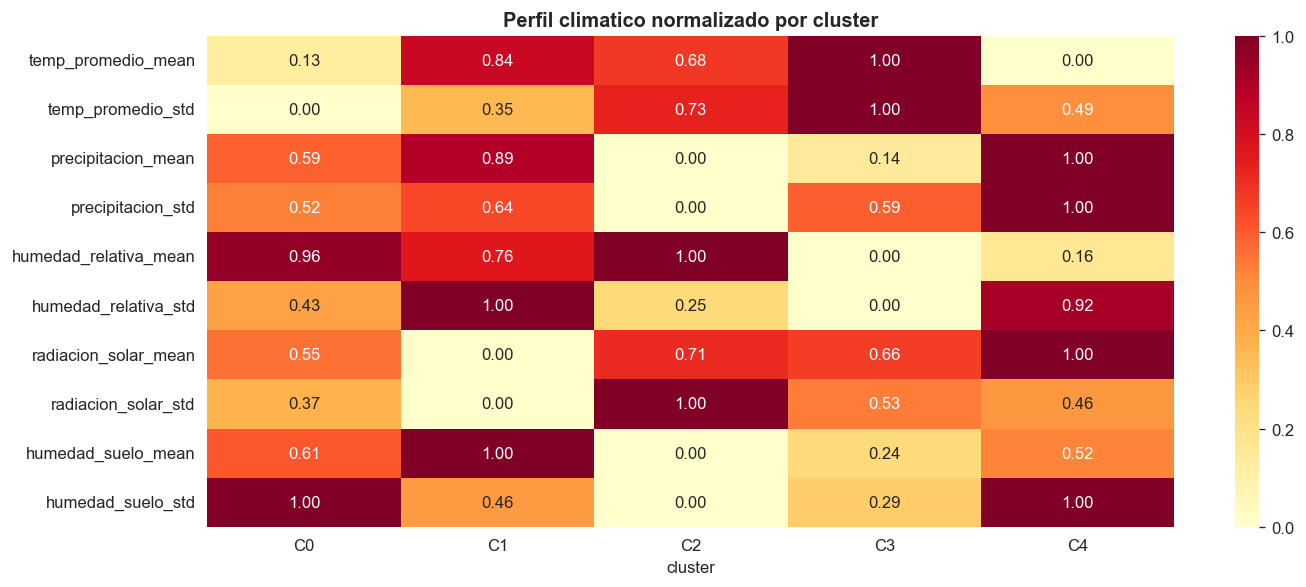


Cluster 0 (2 zonas): Junin | El Tambo, La Libertad | Huamachuco
  Pisos: sierra
  Temp media: 10.4C | Precip: 1.16 | Hum. suelo: 0.49

Cluster 1 (4 zonas): San Martin | Moyobamba, Junin | Perene, Junin | Rio Tambo, San Martin | Tocache
  Pisos: selva_alta, selva_alto_mayo, selva_baja, selva_huallaga
  Temp media: 22.7C | Precip: 1.61 | Hum. suelo: 0.57

Cluster 2 (2 zonas): Ica | Chincha Alta, La Libertad | Viru
  Pisos: costa
  Temp media: 20.0C | Precip: 0.27 | Hum. suelo: 0.36

Cluster 3 (2 zonas): Piura | Sullana, Piura | Tambogrande
  Pisos: bosque_seco, valle_chira
  Temp media: 25.6C | Precip: 0.49 | Hum. suelo: 0.41

Cluster 4 (2 zonas): Puno | Ayaviri, Puno | Ilave
  Pisos: altiplano_lacustre, puna_alta
  Temp media: 8.3C | Precip: 1.78 | Hum. suelo: 0.47


In [7]:
# ====================================================================
# Heatmap de centroides climaticos por cluster
# ====================================================================
cent = zonas.groupby("cluster")[FEATURES_ZONA].mean()
cent_norm = (cent - cent.min()) / (cent.max() - cent.min() + 1e-9)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(cent_norm.T, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax)
ax.set_title("Perfil climatico normalizado por cluster", fontweight="bold")
ax.set_xticklabels([f"C{i}" for i in cent.index])
plt.tight_layout()
plt.savefig(RUTA_FIG / "06a_heatmap_zonas.png", dpi=150, bbox_inches="tight")
plt.show()

# Resumen narrativo por cluster
for c in sorted(zonas["cluster"].unique()):
    sub = zonas[zonas["cluster"] == c]
    print(f"\nCluster {c} ({len(sub)} zonas): {', '.join(sub['etiqueta'])}")
    print(f"  Pisos: {', '.join(sorted(sub['piso_ecologico'].unique()))}")
    print(f"  Temp media: {sub['temp_promedio_mean'].mean():.1f}C | "
          f"Precip: {sub['precipitacion_mean'].mean():.2f} | "
          f"Hum. suelo: {sub['humedad_suelo_mean'].mean():.2f}")


## 6. Produccion como variable descriptiva (a posteriori)

La produccion NO se uso para construir clusters. Aqui se describe que produce cada
tipologia agroclimatica: que cultivos se concentran y su volumen. Esto responde la
pregunta agronomica real: *"que se cultiva en cada tipo de clima"*.


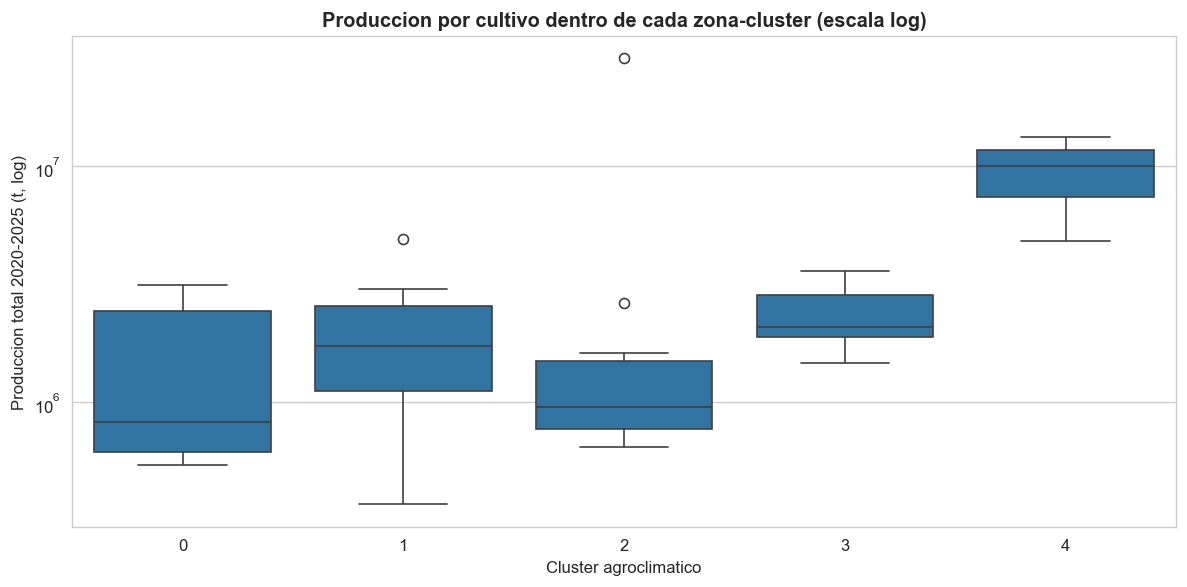


Cluster 0 - cultivos dominantes:
  papa                  : 5,568,473 t
  alfalfa               : 829,310 t
  avena_forrajera       : 614,216 t
  maiz_choclo           : 540,869 t

Cluster 1 - cultivos dominantes:
  arroz_cascara         : 4,913,001 t
  platano               : 3,791,539 t
  palma_aceitera        : 3,021,208 t
  pina                  : 2,527,248 t
  naranja               : 1,734,258 t

Cluster 2 - cultivos dominantes:
  cana_para_azucar      : 28,614,989 t
  uva                   : 2,632,080 t
  palta                 : 2,012,376 t
  arroz_cascara         : 1,613,590 t
  mandarina             : 1,106,304 t

Cluster 3 - cultivos dominantes:
  cana_para_azucar      : 3,614,281 t
  arroz_cascara         : 2,860,924 t
  platano               : 2,091,358 t
  mango                 : 1,882,343 t
  uva                   : 1,465,184 t

Cluster 4 - cultivos dominantes:
  avena_forrajera       : 13,294,902 t
  alfalfa               : 10,029,664 t
  papa                  : 4,821,686

In [8]:
# ====================================================================
# Caracterizacion productiva de cada zona-cluster
# ====================================================================
# Produccion total por (distrito, cultivo) -> se etiqueta con el cluster de su zona.
prod = (df.groupby(["distrito", "cultivo"], as_index=False)["produccion_ton"].sum())
prod = prod.merge(zonas[["distrito", "cluster", "region"]], on="distrito", how="left")
prod = prod[prod["produccion_ton"] > 0]

# Boxplot (escala log) de produccion por cluster
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=prod, x="cluster", y="produccion_ton", ax=ax)
ax.set_yscale("log")
ax.set_title("Produccion por cultivo dentro de cada zona-cluster (escala log)", fontweight="bold")
ax.set_xlabel("Cluster agroclimatico"); ax.set_ylabel("Produccion total 2020-2025 (t, log)")
plt.tight_layout()
plt.savefig(RUTA_FIG / "06a_produccion_por_cluster.png", dpi=150, bbox_inches="tight")
plt.show()

# Top cultivos por cluster
for c in sorted(zonas["cluster"].unique()):
    top = (prod[prod["cluster"] == c].groupby("cultivo")["produccion_ton"].sum()
           .sort_values(ascending=False).head(5))
    print(f"\nCluster {c} - cultivos dominantes:")
    for cult, val in top.items():
        print(f"  {cult:<22}: {val:,.0f} t")


## 7. Mapa de zonas-cluster (Folium)

Cada distrito proxy NASA coloreado por su tipologia agroclimatica.


In [9]:
# ====================================================================
# Mapa interactivo de zonas-cluster
# ====================================================================
try:
    import folium
    from branca.element import Element
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "folium==0.19.5"], check=True)
    import folium
    from branca.element import Element

COORDS = pd.DataFrame([
    {"distrito": "Chincha Alta", "lat": -13.4099, "lon": -76.1324},
    {"distrito": "Viru", "lat": -8.4143, "lon": -78.7524},
    {"distrito": "Huamachuco", "lat": -7.8121, "lon": -78.0487},
    {"distrito": "Cascas", "lat": -7.4797, "lon": -78.8178},
    {"distrito": "Tambogrande", "lat": -4.9269, "lon": -80.3447},
    {"distrito": "Sullana", "lat": -4.9039, "lon": -80.6853},
    {"distrito": "Canchaque", "lat": -5.3760, "lon": -79.6098},
    {"distrito": "Moyobamba", "lat": -6.0344, "lon": -76.9742},
    {"distrito": "Tocache", "lat": -8.1877, "lon": -76.5205},
    {"distrito": "Perene", "lat": -10.9489, "lon": -75.2264},
    {"distrito": "Rio Tambo", "lat": -11.1656, "lon": -74.2353},
    {"distrito": "El Tambo", "lat": -12.0313, "lon": -75.2222},
    {"distrito": "Ilave", "lat": -16.0866, "lon": -69.6354},
    {"distrito": "Ayaviri", "lat": -14.8864, "lon": -70.5889},
])


def _hex(rgb):
    return "#{:02x}{:02x}{:02x}".format(int(rgb[0]*255), int(rgb[1]*255), int(rgb[2]*255))


zmap = zonas.merge(COORDS, on="distrito", how="left")
colors = {c: _hex(PALETTE[int(c) % len(PALETTE)]) for c in sorted(zonas["cluster"].unique())}

m = folium.Map(location=[-9.5, -75.5], zoom_start=5, tiles="CartoDB positron")
for _, row in zmap.iterrows():
    if pd.isna(row["lat"]):
        continue
    col = colors[int(row["cluster"])]
    folium.CircleMarker(
        location=[row["lat"], row["lon"]], radius=9, color=col, weight=2,
        fill=True, fill_color=col, fill_opacity=0.85,
        popup=f"<b>{row['region']} | {row['distrito']}</b><br>Cluster: {int(row['cluster'])}"
              f"<br>Piso: {row['piso_ecologico']}",
        tooltip=f"C{int(row['cluster'])}: {row['distrito']}",
    ).add_to(m)

legend = "".join(
    f'<div><span style="background:{colors[c]};width:14px;height:14px;display:inline-block;'
    f'margin-right:6px;border:1px solid #333;"></span>Cluster {c}</div>'
    for c in sorted(zonas["cluster"].unique()))
m.get_root().html.add_child(Element(
    f'<div style="position:fixed;bottom:24px;left:24px;z-index:9999;background:white;'
    f'padding:10px;border:1px solid #ccc;border-radius:4px;font-size:12px;">'
    f'<b>Zonas agroclimaticas</b><br>{legend}</div>'))

ruta_mapa = RUTA_FIG / "06a_mapa_zonas.html"
m.save(str(ruta_mapa))
print(f"Mapa exportado: {ruta_mapa}")


Mapa exportado: C:\Users\USER\OneDrive\Escritorio\Github\DM_TF\OUTPUTS\figures\06a_mapa_zonas.html


## 8. Exportacion y conclusiones

In [10]:
# ====================================================================
# Exportacion de resultados
# ====================================================================
zonas.to_csv(RUTA_OUT / "06a_zonas_clusters.csv", index=False, encoding="utf-8-sig")
prod.to_csv(RUTA_OUT / "06a_produccion_por_zona.csv", index=False, encoding="utf-8-sig")

print("=" * 60)
print("CONCLUSIONES - Opcion A (tipologias agroclimaticas)")
print("=" * 60)
print(f"K = {K_ZONA} zonas-cluster | Silhouette = {sil:.3f}")
print("- La unidad clusterizada es la ZONA CLIMATICA (distrito), no el cultivo.")
print("- Interpretacion limpia: tipologias agroclimaticas del territorio.")
print("- La produccion describe que se cultiva en cada tipo de clima (no es input).")
print("- Exportado: 06a_zonas_clusters.csv, 06a_produccion_por_zona.csv")


CONCLUSIONES - Opcion A (tipologias agroclimaticas)
K = 5 zonas-cluster | Silhouette = 0.415
- La unidad clusterizada es la ZONA CLIMATICA (distrito), no el cultivo.
- Interpretacion limpia: tipologias agroclimaticas del territorio.
- La produccion describe que se cultiva en cada tipo de clima (no es input).
- Exportado: 06a_zonas_clusters.csv, 06a_produccion_por_zona.csv
